In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://cooking-colour-showcase-plain.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [3]:
# 데이터 생성
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})

평균(Mean)   : 7.429
중앙값(Median): 7.422
최빈값(Mode)  : 10.000
표준편차(Std) : 1.393


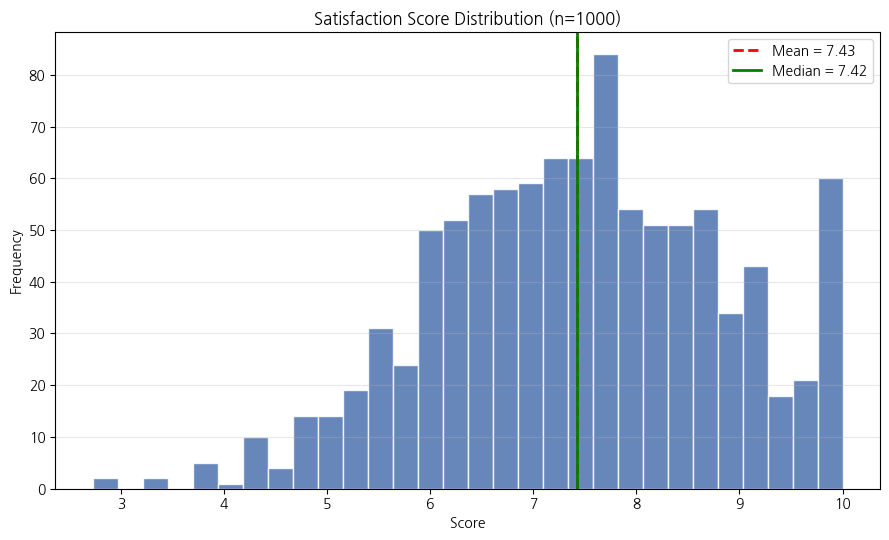

In [6]:
# 아래를 수행해 보세요:
# [문제 2] 여기에 코드를 작성해주세요.

from scipy import stats

# 1) 평균, 중앙값, 최빈값, 표준편차
mean_val = df1['score'].mean()
median_val = df1['score'].median()
mode_val = stats.mode(np.round(df1['score'], 1), keepdims=True).mode[0]
std_val = df1['score'].std()

print(f"평균(Mean)   : {mean_val:.3f}")
print(f"중앙값(Median): {median_val:.3f}")
print(f"최빈값(Mode)  : {mode_val:.3f}")
print(f"표준편차(Std) : {std_val:.3f}")

# 2) 히스토그램 + 평균/중앙값 선
plt.figure(figsize=(9, 5.5))
plt.hist(df1['score'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')

plt.title('Satisfaction Score Distribution (n=1000)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 데이터를 어떻게 읽을까요?
# [문제 1] 여기에 의견을 작성해주세요.
좋은 질문들이네요. 실제 결과값 기준으로 하나씩 짚어볼게요.

## 1. 평균과 중앙값 차이

**평균 7.429 vs 중앙값 7.422 → 차이 0.007**, 사실상 거의 없다고 봐도 됩니다.

- 이렇게 두 값이 거의 같으면 데이터가 **좌우 대칭에 가까운 분포**라는 신호입니다. 실제로 이 데이터는 `np.random.normal(7.5, 1.5, 1000)`으로 만든 정규분포 기반이라서 대칭성이 잘 보존돼 있습니다.
- 히스토그램을 보면 6~8점 구간에 데이터가 몰려있고 좌우로 완만하게 퍼지는 종형(bell-shape) 형태가 보입니다.
- 다만 오른쪽 끝(9~10점)에 막대가 다시 살짝 올라오는 게 보이실 텐데, 이건 원래 정규분포 모양이 아니라 **`np.clip(..., 1, 10)`으로 10을 넘는 값들을 강제로 10에 눌러 담은 인위적 효과**입니다. 이런 값들이 오른쪽 끝을 끌어올리긴 하지만, 반대쪽 끝(1~3점)도 비슷하게 눌려있어서 서로 상쇄되다 보니 평균·중앙값 자체는 크게 왜곡되지 않은 겁니다.

## 2. 최빈값이 평균보다 높은 경우 (여기 해당)

여기서는 **최빈값 10.0 > 평균 7.429**로, 질문 주신 것과 반대 케이스입니다.

- 원칙적으로 "최빈값 > 평균"이면 분포가 **왼쪽(음)으로 치우친(left-skewed)** 모양, 즉 오른쪽에 정점이 있고 왼쪽으로 긴 꼬리가 나오는 형태를 의심해볼 수 있습니다.
- 하지만 이 데이터에서는 그게 **진짜 왜도(skewness)가 아니라 clipping 아티팩트**입니다. 10점을 준 "진짜 매우 만족한 고객"이 실제로 많아서가 아니라, 정규분포에서 10을 초과하는 값들이 전부 10 하나의 값으로 뭉쳐버려서 그 지점에 인위적인 봉우리(spike)가 생긴 겁니다.
- 반대로 최빈값이 평균보다 **낮았다면** (예: 최빈값 6, 평균 7.4), 이건 낮은 점수를 준 고객 수가 특정 구간에 많이 몰려 있다는 뜻이고, 오른쪽으로 긴 꼬리를 가진 **오른쪽 치우침(right-skewed)** 분포를 의심하게 됩니다.
- 👉 실무에서 중요한 포인트: 이런 clipping/스케일 제한이 있는 설문(1~10점 척도)에서는 최빈값만 보고 "만족도가 높다/낮다"를 단정하면 안 되고, 히스토그램 전체 모양과 함께 봐야 합니다.

## 3. 마케팅 전략 제안

이 데이터 자체는 임의 생성된 정규분포라 실제 인사이트로 쓰기엔 한계가 있지만, 이런 분포 형태를 실제 고객 만족도 조사에서 얻었다고 가정하면:

- **중앙에 몰린 대다수(6~8점) 고객**: 만족은 하지만 열성 팬은 아닌 계층 → 리텐션 프로그램, 개인화 혜택으로 8~9점대로 끌어올리는 전략
- **낮은 점수(3~5점) 소수 그룹**: 이탈 위험군 → 원인 파악을 위한 개별 인터뷰나 불만 접수 채널 강화
- **10점(clipping 구간) 고객**: 진짜 최고 만족 고객일 수도 있지만, 위에서 설명한 것처럼 데이터 특성상 과대평가됐을 가능성도 염두에 두고 실제 설문 응답(서술형 피드백 등)을 교차 확인
- 표준편차(1.393)가 크지 않은 편이라 전반적으로 고객 반응이 안정적 → 급격한 캠페인보다는 점진적 만족도 개선(예: 응대 속도, 사후관리) 쪽에 집중하는 게 효율적일 수 있습니다

In [7]:
# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

              mean      median
region                        
A       292.506637  294.324483
B       347.594909  287.347488


<Figure size 700x550 with 0 Axes>

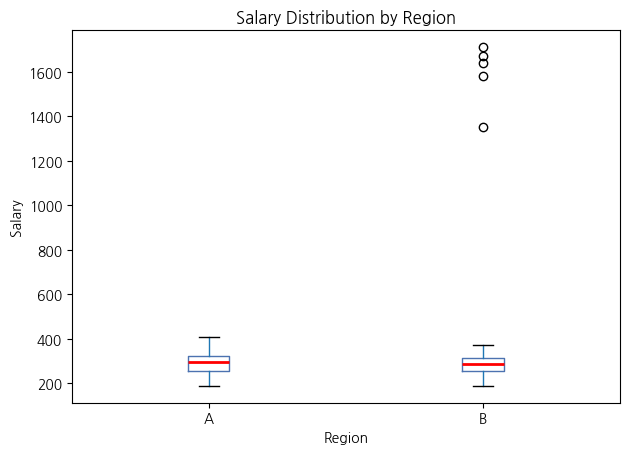

In [8]:
# 아래를 수행해 보세요:
# [문제 2] 여기에 코드를 작성해주세요.

# 1) 지역별 평균, 중앙값
summary = df2.groupby('region')['salary'].agg(['mean', 'median'])
print(summary)

# 2) 지역별 박스플롯
plt.figure(figsize=(7, 5.5))
df2.boxplot(column='salary', by='region', grid=False,
            boxprops=dict(color='#4C72B0'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Salary Distribution by Region')
plt.suptitle('')  # pandas 기본 subtitle 제거
plt.xlabel('Region')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

# 데이터를 어떻게 읽을까요?
# [문제 2] 여기에 의견을 작성해주세요.

## 1. 평균 연봉 비교

**A 지역 평균: 292.51 vs B 지역 평균: 347.59** → B가 약 55만큼 더 높습니다.

- 단순히 숫자만 보면 "B 지역이 A보다 연봉이 높다"고 착각하기 쉽습니다.
- 하지만 B 지역 구성을 보면 일반 소득자 95명(평균 280)은 오히려 A보다 낮은 수준이고, 고소득자 5명(평균 1500)이 전체 평균을 크게 끌어올린 겁니다.
- 즉 이 평균 차이는 "B 지역 전반이 잘 번다"는 뜻이 아니라, **소수의 극단값이 평균을 왜곡시킨 결과**입니다.

## 2. 중앙값 비교

**A 지역 중앙값: 294.32 vs B 지역 중앙값: 287.35** → 이번엔 오히려 A가 B보다 살짝 높습니다.

- 평균으로 보면 B가 55 높은데, 중앙값으로 보면 A가 7 정도 높습니다. **순위가 완전히 뒤집힌 것**이죠.
- 이건 B 지역에서 "중간에 있는 사람(50번째 순위 근처)"은 여전히 일반 소득자 그룹(280 근처)에 속해 있다는 뜻입니다. 즉 B 지역 사람 100명 중 절반 이상은 A 지역 사람들과 비슷하거나 오히려 약간 낮은 연봉을 받고 있습니다.

## 3. 극단값의 영향

- 평균은 모든 값을 더해서 나누는 방식이라 **극단값 5명의 합(약 7500)이 전체 합에 그대로 반영**됩니다. 그래서 100명 중 5명(5%)에 불과한데도 평균을 60가까이 끌어올릴 수 있는 겁니다.
- 중앙값은 "가운데 순위"만 보기 때문에 극단값이 아무리 커도(1500이든 15000이든) 순위 자체는 안 바뀌어서 영향을 거의 안 받습니다.
- 👉 **평균이 중앙값보다 극단값에 훨씬 민감**합니다. 이번 케이스가 그 교과서적인 예시입니다.

## 4. 박스플롯 관찰

- 박스플롯에서 동그라미(○)로 표시된 점들이 **이상치(outlier)**입니다. B 지역 위쪽에 1350~1700 부근에 찍힌 동그라미 5개가 바로 그 고소득자들입니다.
- **사분위 범위(박스의 높이)** 자체는 A와 B가 비슷하게 200~400 사이에 몰려 있어서, "중간 90% 이상"의 사람들은 두 지역이 거의 비슷한 분포를 가진다는 걸 알 수 있습니다.
- 즉 박스 자체(1분위~3분위, 중앙선)는 A와 B가 큰 차이가 없고, 차이는 오직 이상치 구간에서만 발생합니다.

## 5. 평균만 볼 때의 오해

- "B 지역 평균 연봉이 55만큼 더 높다"는 문장만 보고 정책이나 마케팅 타겟팅을 하면, **실제로는 B 지역 대다수 주민이 A 지역보다 소득이 낮다**는 진짜 그림을 놓치게 됩니다.
- 예를 들어 지역별 소비력 예측, 상품 가격대 설정, 광고 타겟팅을 평균 기준으로 한다면 B 지역을 과대평가해서 잘못된 의사결정을 내릴 위험이 있습니다.
- **중앙값이 더 유용한 경우**: 소득, 자산, 부동산 가격처럼 소수의 극단값(초고소득자, 초고가 매물)이 존재하기 쉬운 데이터에서는 "일반적인 사람의 상황"을 보고 싶을 때 중앙값을 쓰는 게 훨씬 대표성이 높습니다. (실제로 정부 통계에서 소득 얘기할 때 "평균소득"보다 "중위소득"을 많이 쓰는 이유도 이거랑 같은 맥락입니다.)

In [9]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

            mean        std        min         max
class                                             
1반     75.724316   7.062710  60.685416   92.175893
2반     73.728848  22.340818   0.000000  130.000000


<Figure size 700x550 with 0 Axes>

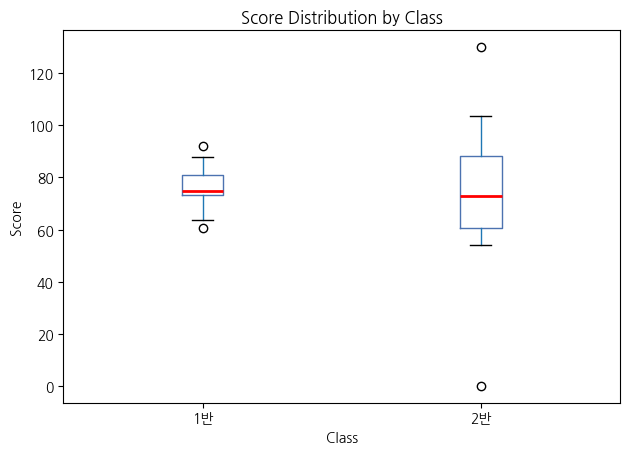

In [10]:
# 아래를 수행해 보세요:
# [문제 3] 여기에 코드를 작성해주세요.

# 1) 반별 평균, 표준편차, 최소/최대값
summary = df3.groupby('class')['score'].agg(['mean', 'std', 'min', 'max'])
print(summary)

# 2) 반별 박스플롯
plt.figure(figsize=(7, 5.5))
df3.boxplot(column='score', by='class', grid=False,
            boxprops=dict(color='#4C72B0'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Score Distribution by Class')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

# 데이터를 어떻게 읽을까요?
# [문제 3] 여기에 의견을 작성해주세요.

## 1. 어느 반이 분산이 크고, 왜?

**2반의 표준편차가 22.34로 1반(7.06)보다 약 3배 이상 큽니다.**

- 분포의 퍼짐 정도는 **표준편차, 분산, 범위(최댓값-최솟값), 사분위범위(IQR)** 같은 지표로 확인할 수 있습니다.
- 2반의 범위는 130 - 0 = 130점, 1반은 92.18 - 60.69 = 약 31.5점으로 4배 넘게 차이가 납니다.
- 이 차이의 원인은 명확합니다. 2반에 인위적으로 추가된 **극단값 0점과 130점** 두 개 때문입니다. 이 두 값만 없다면 2반의 나머지 28명은 평균 75, 표준편차 15 정규분포라 1반과 비슷한 수준의 퍼짐을 보였을 겁니다.
- 표준편차는 각 값과 평균의 차이를 제곱해서 반영하기 때문에, 극단값이 하나만 있어도 그 영향이 제곱으로 커집니다. 그래서 이상값이 포함되면 표준편차와 범위가 실제 "전형적인 학생들의 편차"보다 훨씬 부풀려져서 나타납니다.

## 2. 이상값이 평균에 미친 영향

**2반 평균 73.73 vs 1반 평균 75.72** → 오히려 2반이 1반보다 2점 낮게 나왔습니다.

- 0점과 130점이 서로 반대 방향으로 작용해서 어느 정도 상쇄됐습니다. 130점이 평균을 끌어올리는 효과와 0점이 끌어내리는 효과가 비슷해서, 최종 평균은 "일반 학생들만 있었을 때"와 크게 다르지 않게 나온 겁니다.
- 하지만 이건 **우연히 상쇄된 것**이지, 이상값의 영향이 없었다는 뜻은 아닙니다. 만약 130점 학생이 없고 0점만 있었다면 평균은 훨씬 더 떨어졌을 거고, 반대로 0점 없이 130점만 있었다면 평균이 더 올라갔을 겁니다.
- 박스플롯의 빨간 중앙값 선을 보면 2반 중앙값이 대략 73 근처에서 평균(73.73)과 거의 비슷한 위치에 있는데, 이 역시 두 극단값이 서로 반대 방향이라 우연히 균형을 이룬 결과로 봐야지, "2반 분포가 원래 대칭적이고 안정적이다"라고 해석하면 안 됩니다.

## 3. 박스플롯으로 본 이상값

- 박스플롯에서 박스와 수염(whisker) 범위를 벗어난 값은 **동그라미(○)로 개별 표시**됩니다. 2반 위쪽의 130점, 아래쪽의 0점이 정확히 그렇게 그려져 있습니다.
- 두 반의 **박스(사분위범위) 크기**를 비교해보면, 1반은 박스 높이가 좁고(대략 70~80 사이) 수염도 짧은 반면, 2반은 박스 자체가 훨씬 넓고(대략 60~88 사이) 위아래 수염 길이도 깁니다. 즉 이상값 두 개를 빼고 봐도 2반 내부 학생들(표준편차 15 세팅) 자체가 1반(표준편차 8)보다 더 넓게 퍼져 있다는 걸 박스 크기로 확인할 수 있습니다.

## 4. 평균만 볼 때의 오해

- 이번 케이스가 좋은 예시입니다. 교사가 "2반 평균 73.73이 1반 평균 75.72보다 낮으니 2반이 학습 부진하다"고 판단하면 완전히 잘못된 결론입니다.
- 실제로는 2반 학생 28명 중 다수가 1반과 비슷하거나 더 잘했을 수도 있고, 단지 극단적인 사례 2명(0점 학생 하나, 130점 학생 하나)이 우연히 평균을 비슷한 수준으로 맞춰놓은 것뿐입니다.
- 만약 0점 학생이 실제로 시험을 못 봤거나 결시한 경우라면, 이 학생 하나 때문에 반 전체 평균이 왜곡되고 "2반 수업이 부실하다"는 잘못된 평가로 이어질 수 있습니다.
- 그래서 표준편차나 박스플롯을 함께 봐야 하는 이유가 명확합니다. **평균은 "중심 위치"만 알려주고, 표준편차·IQR·박스플롯은 "그 중심 주변에 데이터가 얼마나 고르게 모여있는지"를 알려줍니다.** 이 둘을 같이 봐야 "평균은 비슷한데 왜 이렇게 반 분위기가 다르게 느껴질까"와 같은 실제 현장의 체감을 데이터로 설명할 수 있습니다.
- 실무 팁: 이런 경우 이상값을 포함한 평균과, 이상값을 제외한(trimmed mean) 평균을 같이 제시하거나, 평균 대신 중앙값을 보조 지표로 함께 보고하는 게 훨씬 안전한 해석을 제공합니다.

In [11]:
# 2반 데이터만 추출
class2_scores = df3[df3['class'] == '2반']['score']

# 1) IQR 계산
Q1 = class2_scores.quantile(0.25)
Q3 = class2_scores.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"이상값 판별 기준: {lower_bound:.2f} ~ {upper_bound:.2f}")

# 2) 이상값 판별 및 제거
outliers = class2_scores[(class2_scores < lower_bound) | (class2_scores > upper_bound)]
class2_filtered = class2_scores[(class2_scores >= lower_bound) & (class2_scores <= upper_bound)]

print(f"\n제거된 이상값: {outliers.tolist()}")
print(f"제거 전 데이터 개수: {len(class2_scores)}개")
print(f"제거 후 데이터 개수: {len(class2_filtered)}개")

# 3) 제거 전/후 평균, 중앙값 비교
before_mean = class2_scores.mean()
after_mean = class2_filtered.mean()
before_median = class2_scores.median()
after_median = class2_filtered.median()

print("\n=== 이상값 제거 전/후 비교 ===")
print(f"제거 전 평균: {before_mean:.3f}  |  제거 후 평균: {after_mean:.3f}")
print(f"제거 전 중앙값: {before_median:.3f}  |  제거 후 중앙값: {after_median:.3f}")
print(f"평균 변화량: {after_mean - before_mean:+.3f}")
print(f"중앙값 변화량: {after_median - before_median:+.3f}")

Q1 = 60.75, Q3 = 88.37, IQR = 27.61
이상값 판별 기준: 19.33 ~ 129.79

제거된 이상값: [0.0, 130.0]
제거 전 데이터 개수: 30개
제거 후 데이터 개수: 28개

=== 이상값 제거 전/후 비교 ===
제거 전 평균: 73.729  |  제거 후 평균: 74.352
제거 전 중앙값: 73.004  |  제거 후 중앙값: 73.004
평균 변화량: +0.623
중앙값 변화량: +0.000


# 데이터를 어떻게 읽을까요?
# [문제 4] 여기에 의견을 작성해주세요.

## 1. 이상값 제거 전후 평균 변화

**제거 전 73.729 → 제거 후 74.352, 변화량 +0.623**

- 제거 후 평균이 중앙값(73.004)에 더 가까워졌다고 볼 수는 있지만, 사실 그 차이는 크지 않습니다. 제거 전 평균-중앙값 차이는 0.725, 제거 후는 1.348로 오히려 **차이가 약간 더 벌어졌습니다.**
- 이유는 이전 답변에서 설명드렸던 것과 같습니다. 0점과 130점이라는 두 이상값이 **서로 반대 방향으로 작용해서 이미 상쇄**되고 있었기 때문에, 둘 다 제거해도 평균이 극적으로 바뀌지 않은 겁니다. (만약 130점만 있고 0점이 없었다면 제거 후 평균이 훨씬 크게 떨어졌을 겁니다.)
- 즉 이번 케이스는 "이상값이 평균에 영향을 안 준다"는 뜻이 아니라, **양쪽 극단값이 우연히 서로를 상쇄해서 이번 데이터에서는 평균 변화가 작게 나타난 특수한 경우**라는 점을 짚고 넘어가야 합니다.
- 중앙값은 제거 전후 완전히 동일(73.004 → 73.004, 변화량 0.000)합니다. 이건 중앙값이 애초에 극단값 두 개의 존재 자체에 전혀 영향받지 않았다는 뜻입니다. 30개 중 가운데 순위에 있는 값이 이상값 제거로 인해 데이터 개수가 30→28로 바뀌어도 여전히 같은 값이었기 때문입니다.

## 2. 왜 IQR 기준을 쓸까?

- IQR은 데이터를 **4등분(사분위)**해서, 하위 25%(Q1)와 상위 25%(Q3) 지점을 구하고, 그 사이 구간(Q3-Q1)을 IQR로 정의합니다.
- 이상값 판별 기준은 보통 `Q1 - 1.5×IQR` 미만이거나 `Q3 + 1.5×IQR` 초과인 값입니다. 이번 결과에서는 19.33~129.79 범위를 벗어난 0점과 130점이 정확히 걸러졌습니다.
- 평균이나 표준편차 기준(예: 평균 ± 2·표준편차)과 비교했을 때 IQR이 더 강건(robust)한 이유는, **Q1과 Q3 자체가 극단값의 영향을 거의 안 받기 때문**입니다. 표준편차는 극단값이 하나만 들어가도 그 값의 제곱이 반영돼서 크게 부풀려지지만, 사분위수는 "몇 번째 순위에 있는 값이냐"만 보기 때문에 극단값이 아무리 크거나 작아도 순위 자체는 안 바뀝니다.
- 이번 결과에서도 IQR = 27.61로, 극단값 두 개가 포함된 상태에서도 비교적 합리적인 범위가 계산됐고, 실제로 그 두 극단값을 정확히 걸러내는 데 성공했습니다.

## 3. 이상값을 제거해야 할 때 vs 유지해야 할 때

- **제거하는 것이 적절한 경우**: 입력 오류, 측정 실수, 시스템 오류로 생긴 값 (예: 시험 결시로 자동 입력된 0점, 센서 오작동으로 찍힌 값)
- **유지해야 하는 경우**: 그 이상값 자체가 분석 목적상 중요한 정보인 경우. 예를 들어
  - 130점이 만점 초과 보너스 점수를 포함한 실제 유효한 점수라면, 이건 "우수 학생의 실제 성과"이므로 제거하면 안 됩니다.
  - 투자 전략 분석에서도 마찬가지입니다. 급등/급락 같은 극단적인 수익률을 "이상치"라고 무조건 제거해버리면, 정작 리스크 관리에서 가장 중요한 꼬리 위험(tail risk) 정보를 날려버리는 셈이 됩니다.
- 결론적으로 이상값 제거는 **"왜 그 값이 나왔는가"를 먼저 확인한 뒤** 결정해야지, 기계적으로 IQR 기준에 걸린다고 무조건 지우면 안 됩니다.

## 4. 중앙값 vs 평균, 언제 어떤 게 유용한가

- **평균**: 모든 데이터를 균등하게 반영하므로, 데이터가 대칭적이고 극단값이 없을 때 "전체 총량을 인원수로 나눈 대표값"으로서 의미가 명확합니다. (예: 예산 배분, 총량 계산 등)
- **중앙값**: 극단값이나 왜곡된 분포가 있을 때 "전형적인 개체의 상태"를 더 잘 보여줍니다. 이번 결과처럼 극단값 두 개가 있어도 전혀 흔들리지 않고 73.004로 고정된 게 그 강건성을 보여주는 좋은 예시입니다.
- **함께 보는 것의 장점**: 평균과 중앙값의 차이 자체가 "이 데이터에 이상값이나 비대칭성이 있는지"를 알려주는 진단 지표가 됩니다. 이번처럼 둘의 차이가 크지 않다고 해서 "이상값이 없다"고 단정하면 안 되고 (실제로는 있었죠), 반드시 히스토그램이나 박스플롯 같은 시각화와 함께 봐야 정확한 판단이 가능합니다. 즉 숫자 하나만 보고 결론 내리기보다, **평균+중앙값+시각화(박스플롯) 세 가지를 조합**해서 봐야 이번 사례처럼 "우연히 상쇄된 경우"를 놓치지 않을 수 있습니다.

In [12]:
# 데이터 생성
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})

In [14]:
# 아래를 수행해 보세요:
# [문제 5] 여기에 코드를 작성해주세요.

# 1) 각 변수의 데이터 타입 확인
print("=== 데이터 타입 (dtype) ===")
print(df5.dtypes)

print("\n=== 각 컬럼 샘플 값 (참고용) ===")
print(df5.head())

# 2) 변수 유형 분류 (의미 기준)
variable_classification = {
    'age':          {'dtype': str(df5['age'].dtype),          'type': '이산형 (numeric-discrete)'},
    'coffee_type':  {'dtype': str(df5['coffee_type'].dtype),  'type': '범주형 (categorical)'},
    'size':         {'dtype': str(df5['size'].dtype),         'type': '서열형 범주 (ordinal-categorical)'},
    'price':        {'dtype': str(df5['price'].dtype),        'type': '연속형 (numeric-continuous)'},
    'satisfaction': {'dtype': str(df5['satisfaction'].dtype), 'type': '서열형 범주 (ordinal-categorical)'},
}

classification_df = pd.DataFrame(variable_classification).T
classification_df.columns = ['dtype', '변수 유형']
print("\n=== 변수 유형 분류 결과 ===")
print(classification_df)

=== 데이터 타입 (dtype) ===
age               int64
coffee_type      object
size             object
price           float64
satisfaction      int64
dtype: object

=== 각 컬럼 샘플 값 (참고용) ===
   age coffee_type    size        price  satisfaction
0   48        카페모카   Small  4435.448359             1
1   36          라떼   Small  4849.195869             4
2   48        카페모카   Large  4365.135391             1
3   30       아메리카노  Medium  3979.605848             2
4   21        카페모카   Small  4650.242695             1

=== 변수 유형 분류 결과 ===
                dtype                         변수 유형
age             int64        이산형 (numeric-discrete)
coffee_type    object             범주형 (categorical)
size           object  서열형 범주 (ordinal-categorical)
price         float64      연속형 (numeric-continuous)
satisfaction    int64  서열형 범주 (ordinal-categorical)


# 데이터를 어떻게 읽을까요?
# [문제 5] 여기에 의견을 작성해주세요.

## 1. 숫자처럼 보이지만 실제로는 범주형/서열형인 변수

**`satisfaction`**이 대표적인 경우입니다.

- dtype이 `int64`로 표시되어서 언뜻 보면 나이(`age`)처럼 순수한 이산형 숫자로 착각하기 쉽습니다.
- 하지만 1~5라는 값은 "양"을 나타내는 게 아니라 "만족도 순위"를 나타냅니다. 즉 satisfaction=4가 satisfaction=2보다 "정확히 2배 더 만족했다"는 뜻이 아니라, 그냥 "더 만족했다"는 순서 정보만 유효합니다.
- 이런 변수는 평균을 내는 게 이론적으로 논란의 여지가 있습니다. (실무에서는 관행적으로 평균을 많이 내긴 하지만, 엄밀히는 최빈값이나 중앙값이 더 정확한 대표값입니다.)

한 가지 더 짚을 부분은, **`age`도 완전히 순수한 연속형은 아니라는 점**입니다. 나이는 원래 연속적인 개념(시간의 흐름)이지만, 이 데이터에서는 `np.random.randint`로 정수 단위(18, 19, 20...)만 생성돼서 사실상 이산형으로 다뤄지고 있습니다. 다만 이건 satisfaction처럼 "순서만 의미있는" 경우와는 다르게, 숫자 자체의 크기와 간격이 그대로 의미를 가지므로(48세는 24세보다 정확히 2배 나이가 많다는 게 참) 이산형으로 분류해도 분석상 문제는 없습니다.

## 2. 변수 유형별 적절한 분석/시각화 방법

| 유형 | 해당 변수 | 적절한 통계 요약 | 적절한 시각화 |
|---|---|---|---|
| 연속형 | price | 평균, 표준편차, 사분위수 | 히스토그램, 박스플롯, 밀도플롯(KDE) |
| 이산형 | age | 평균, 중앙값도 가능 (구간이 촘촘하면 연속형처럼 다뤄도 무방) | 히스토그램, 막대그래프 |
| 범주형 | coffee_type | 최빈값, 빈도(카운트), 비율(%) | 막대그래프, 파이차트 |
| 서열형 범주 | size, satisfaction | 최빈값, 중앙값(순위 기준), 빈도표 | **순서를 유지한** 막대그래프, 순서형 박스플롯 |

핵심 차이점 몇 가지:

- **범주형(coffee_type)**: 막대그래프를 그릴 때 막대 순서가 어떻게 배열되든 상관없습니다(순서에 의미가 없으니까). 보통 빈도가 높은 순으로 정렬해서 보기 좋게 만듭니다.
- **서열형(size, satisfaction)**: 막대그래프를 그릴 때 **반드시 원래 순서(Small→Medium→Large, 1→5)를 유지**해야 합니다. 빈도순으로 재배열하면 "순서"라는 핵심 정보가 사라져서 오해를 부를 수 있습니다.
- **연속형(price)과의 상관관계 분석**: `satisfaction`이나 `size`처럼 서열형 변수를 `price`와 비교할 때는 피어슨 상관계수보다 **스피어만 순위상관(Spearman correlation)**을 쓰는 게 이론적으로 더 적합합니다. 피어슨은 "간격이 균등하다"는 가정을 깔고 있는데, 서열형 변수는 그 가정이 성립 안 하기 때문입니다.
- 실무에서 흔한 실수: coffee_type(범주형)을 그냥 숫자로 인코딩(아메리카노=0, 라떼=1, 카페모카=2)해서 회귀분석에 넣는 경우가 있는데, 이건 순서가 없는 변수에 억지로 순서를 부여하는 셈이라 잘못된 결과를 낳습니다. 이런 경우엔 원-핫 인코딩(one-hot encoding)을 써야 합니다.